In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tools.eval_measures import rmse, rmspe
import warnings

warnings.filterwarnings('ignore')

In [2]:
file = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch15/AEP_hourly.csv')
df = pd.read_csv(file, index_col='Datetime', parse_dates=True)
df.sort_index(inplace=True)
df = df.resample('H').max()
df.ffill(inplace=True)

In [3]:
from statsmodels.tsa.seasonal import MSTL

plt.rcParams["figure.figsize"] = [14, 10]

In [4]:
day = 24
week = day * 7
month = round(week * 4.35)
year = round(month * 12)
print(f'''
day = {day} hours
week = {week} hours
month = {month} hours
year = {year} hours
''')


day = 24 hours
week = 168 hours
month = 731 hours
year = 8772 hours



Start by providing the different seasonal cycles you suspect – for example, a daily and weekly seasonal pattern.

In [6]:
mstl = MSTL(df, periods=(day, week))

In [7]:
results = mstl.fit()

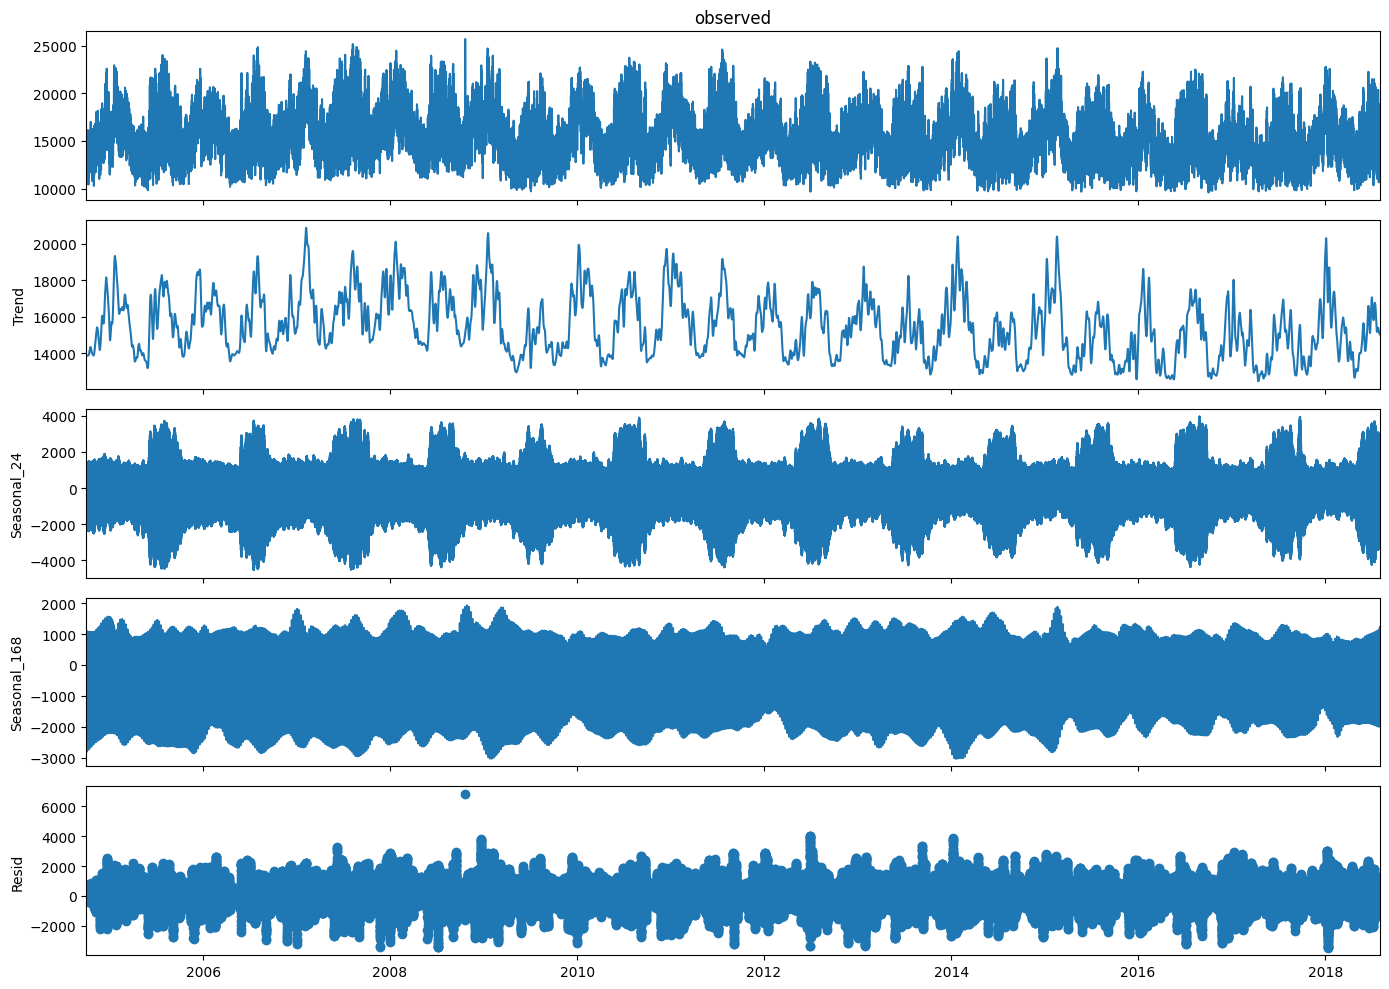

In [8]:
ax = results.plot()
ax.tight_layout()

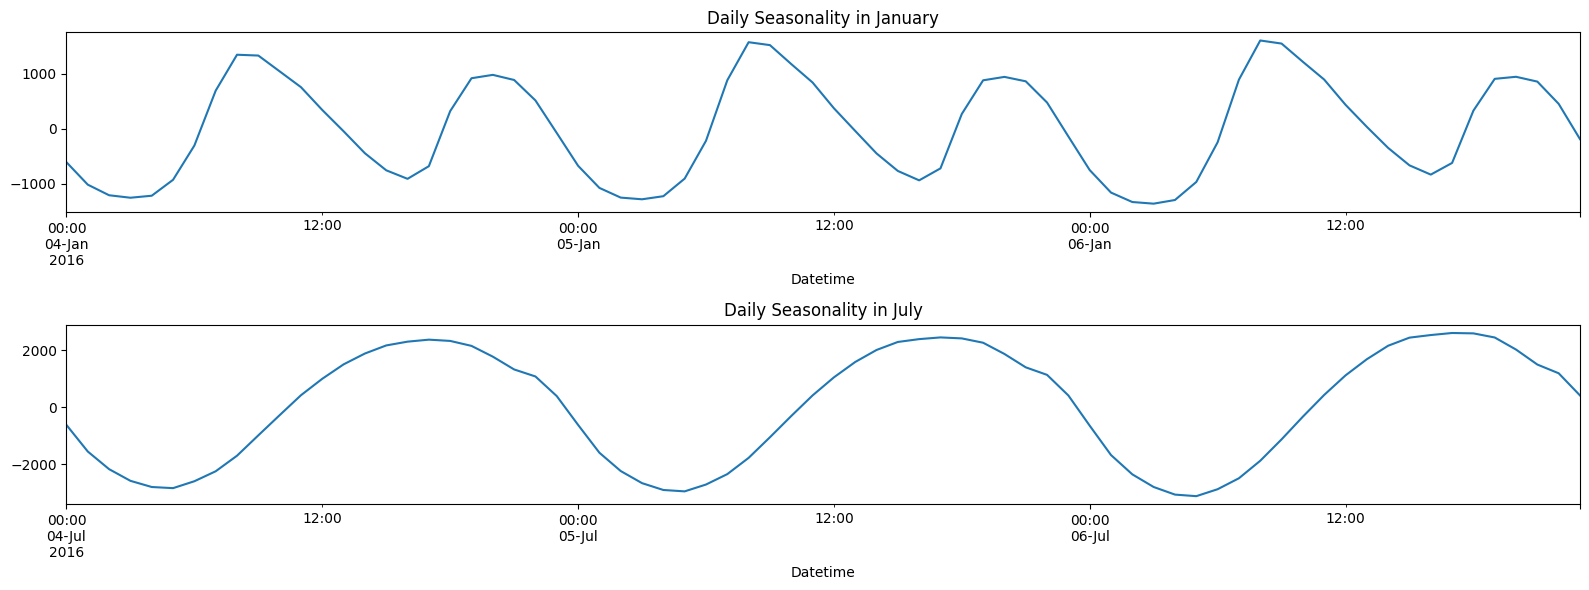

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(16, 6))
(results.seasonal['seasonal_24'].loc['2016-01-04':'2016-01-06'].plot(ax=ax[0], title='Daily Seasonality in January'))
(results.seasonal['seasonal_24'].loc['2016-07-04':'2016-07-06'].plot(ax=ax[1], title='Daily Seasonality in July'))
fig.tight_layout(); plt.show()

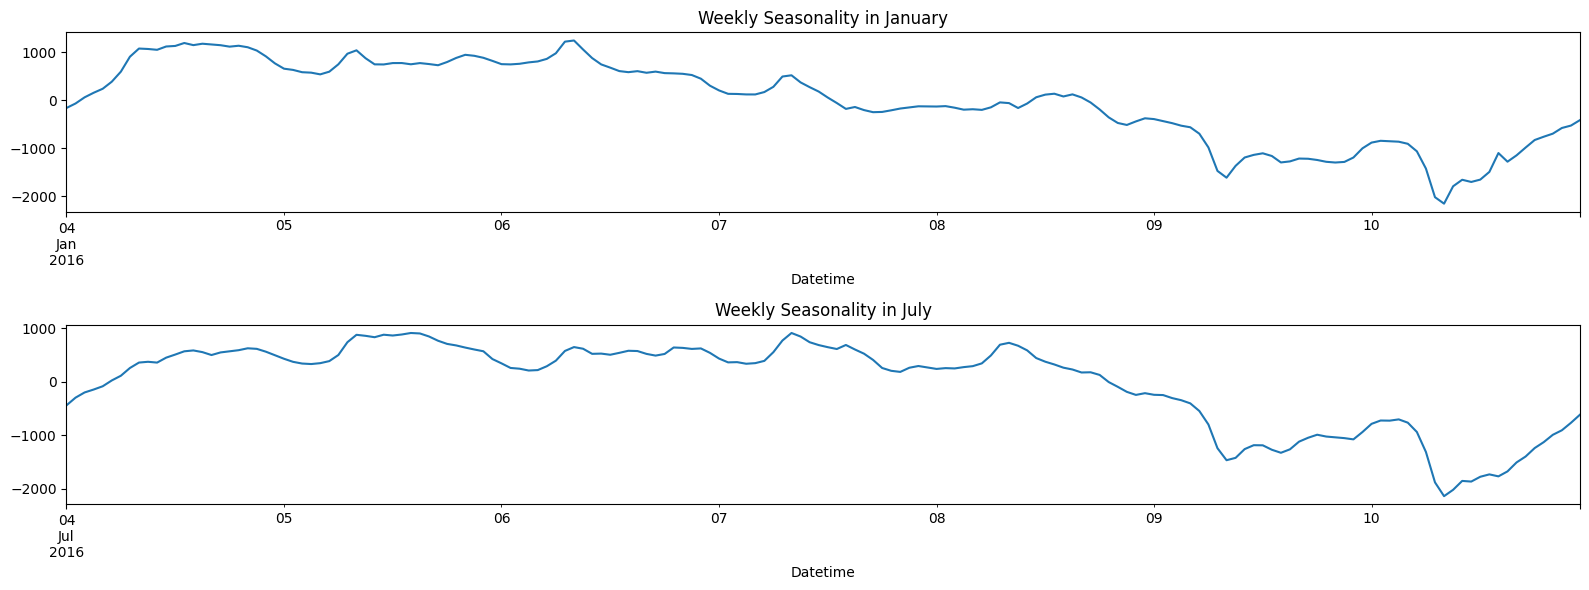

In [10]:
# mask = results.seasonal.index.month==7
fig, ax = plt.subplots(2, 1, figsize=(16, 6))
(results.seasonal['seasonal_168'].loc['2016-01-04':'2016-01-10'].plot(ax=ax[0], title='Weekly Seasonality in January'))
(results.seasonal['seasonal_168'].loc['2016-07-04':'2016-07-10'].plot(ax=ax[1],title='Weekly Seasonality in July'))
fig.tight_layout(); plt.show()

In [11]:
mstl = MSTL(df, periods=(24, 24*7), iterate=4, windows=[121, 121])
results = mstl.fit()

### 2. Forecasting with multiple seasonal patterns using the Unobserved Components Model (UCM)

In [12]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

In [13]:
train = df.iloc[:-month]
test = df.iloc[-month:]

<Axes: xlabel='Datetime'>

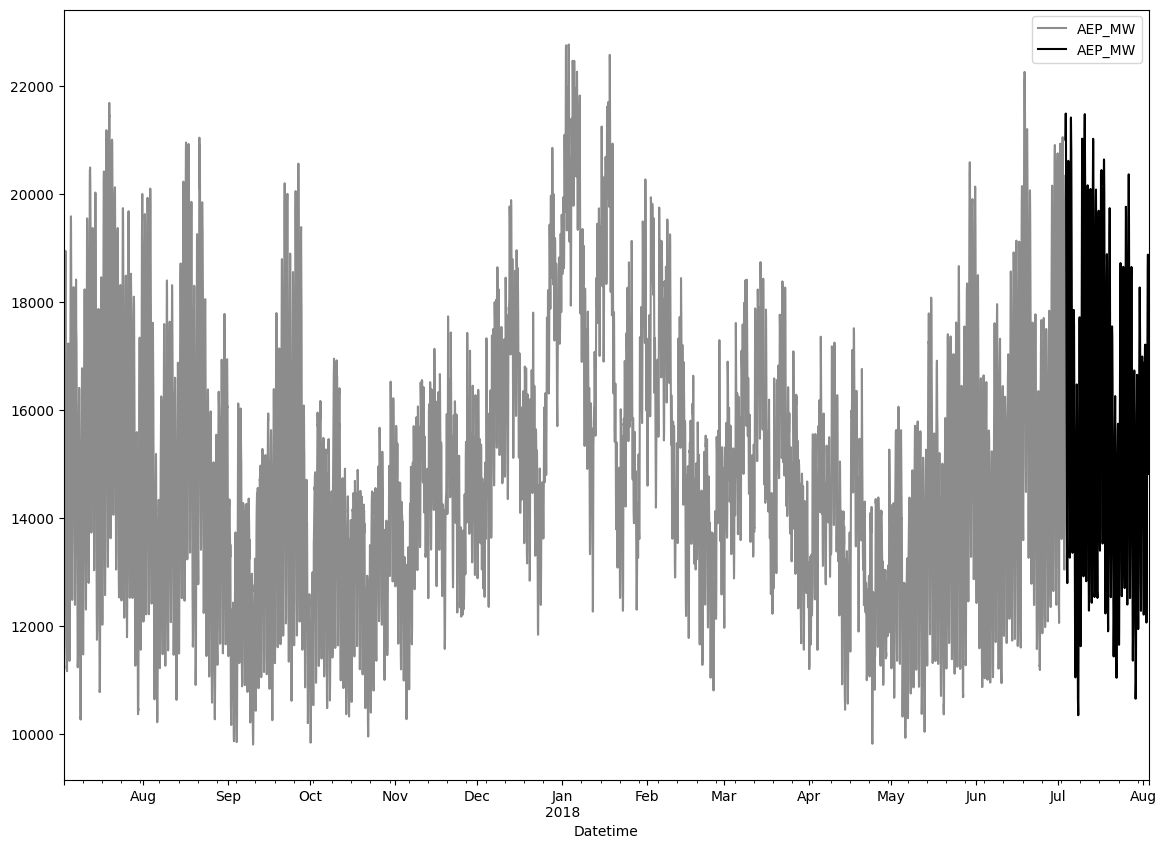

In [14]:
ax = train.iloc[-year:].plot(style='k-', alpha=0.45)
test.plot(ax=ax, style='k')

In [15]:
params = {
    'level': 'dtrend',
    'irregular': True,
    'freq_seasonal': [{'period': day}, {'period': week}, {'period': year}],
    'stochastic_freq_seasonal': [False, False, False]
}

model = UnobservedComponents(train, **params)

In [ ]:
results = model.fit()

In [ ]:
results.summary()

plot_diagnostics is used to diagnose the model's overall performance against the residuals:

In [ ]:
fig = results.plot_diagnostics(figsize=(14, 6))
fig.tight_layout()

You can plot the components, which will produce six subplots using the smoothed results – predicted versus observed, the level component, the trend component, seasonal (24), seasonal (168), and seasonal (8772). The plots for freq_seasonal are too condensed (given the number of observations) to visibly see any pattern for the daily and weekly seasonal components. Instead, you will plot each component individually by slicing the data. For now, use plot_components, but disable the freq_seasonal output, as shown in the following:

In [ ]:
fig = results.plot_components(figsize=(15, 6), freq_seasonal=False, which='smoothed')
fig.tight_layout()

You can access the data behind each component from the results object. For example, you can access freq_seasonal, which should contain a list of three dictionaries, one for each seasonal period, daily, weekly, and yearly, based on what you provided in the key-value pair when you initialized the model (see Step 4). Each dictionary contains six outputs or keys, as shown in the following:

In [ ]:
len(results.freq_seasonal)

In [ ]:
# Plot the daily seasonal component. For easier interpretation, slice the data to show 24 hours (1 day):
daily = pd.DataFrame(results.freq_seasonal[0]['smoothed'], index=train.index, columns=['y']).iloc[:day]
daily['hour_of_day'] = daily.index.strftime(date_format = '%I:%M:%S %p')
daily.plot(y='y', x='hour_of_day', title='Daily Seasonality')

In [ ]:
weekly = pd.DataFrame(results.freq_seasonal[1]['smoothed'], index=train.index, columns=['y']).loc['2004-10-03': '2004-10-10']
weekly['day_name'] = weekly.index.strftime(date_format = '%A')
weekly.plot(y='y', x='day_name', title='Weekly Seasonality')

In [ ]:
annual = pd.DataFrame(results.freq_seasonal[2]['smoothed'], index=train.index, columns=['y']).loc['2005']
annual['month'] = annual.index.strftime(date_format = '%B')
ax = annual.plot(y='y', x='month', title='Annual Seasonality')

In [ ]:
prediction = results.predict(start=test.index.min(), end=test.index.max())
test.plot(style='k--', alpha=0.5)
prediction.plot(style='k')
plt.legend(['Actual', 'Predicted'])
plt.title('Out-of-Sample Forecast: Actual vs Predicted')

In [ ]:
rmspe(test['y'], prediction)

In [ ]:
rmse(test['y'], prediction)

In [ ]:
params = {'level':'dtrend',
    'irregular':True,
    'freq_seasonal': [{'period': day, 'harmonics':1}, {'period': week, 'harmonics':1}, {'period': year, 'harmonics':1}],
    'stochastic_freq_seasonal': [False, False, False]
}

model = UnobservedComponents(train, **params)
results = model.fit()

In [ ]:
rmspe(test['y'], prediction)

In [ ]:
rmse(test['y'], prediction)

### 3. Forecasting time series with multiple seasonal patterns using Prophet

In [1]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot